In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.bat_hd_system import BatHeadDirectionSystem
from grid_cells.plot_tools import angular_error, smooth_ts
import os
from concurrent.futures import ThreadPoolExecutor



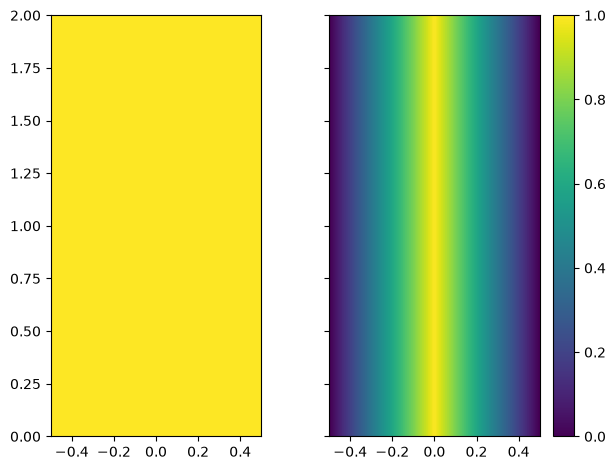

In [2]:
azimuth = np.linspace(0, 2 * np.pi, 100)
polar = np.linspace(-np.pi / 2, np.pi / 2, 100)

azimuth, polar = np.meshgrid(azimuth, polar)


def sphere_to_toroid(azimuth, polar):
    pair_1 = np.stack([azimuth, polar], axis=-1)
    pair_2 = np.stack(
        [
            (azimuth + np.pi) % (2 * np.pi),
            (np.pi - polar) % (2 * np.pi),
        ],
        axis=-1,
    )
    return pair_1, pair_2


pair_1, pair_2 = sphere_to_toroid(azimuth, polar)

fig, ax = plt.subplots(ncols=2,sharey=True)
vmin, vmax = 0,1
ax[0].imshow(
    np.abs(angular_error(pair_1, pair_2)[...,0].T),
    extent=[-0.5, 0.5, 0, 2],
    origin="lower",
    vmin=vmin,vmax=vmax
)
cm = ax[1].imshow(
    np.abs(angular_error(pair_1, pair_2)[..., 1].T),
    extent=[-0.5, 0.5, 0, 2],
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)
fig.colorbar(cm, ax=ax[1])
fig.tight_layout()



In [12]:
net = BatHeadDirectionSystem(
    size=1
)
net.warm_up(initial_dir = np.array([np.pi,np.pi]))

Ran warm up for 161 steps


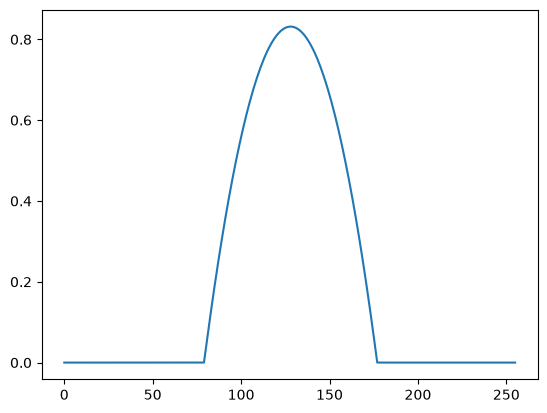

In [13]:
plt.plot(net.pitch_ring.s)

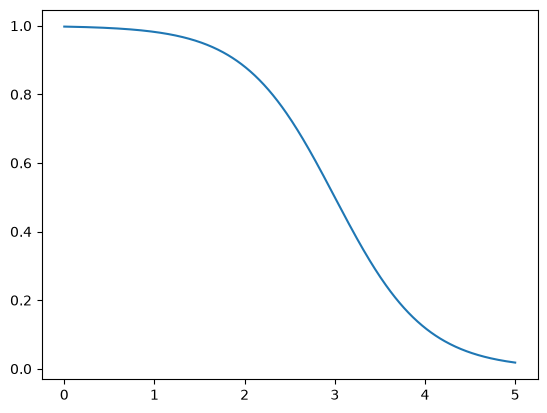

In [5]:
x = np.linspace(0,5,500)
y = 1.0 / (
            1.0 + np.exp(2 * (x - 3))
        )
plt.plot(x,y)